In [1]:
import os, glob, re
import xarray as xr
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

Reading: Low
20 clusters
Reading: Medium
75 clusters
Reading: High
125 clusters


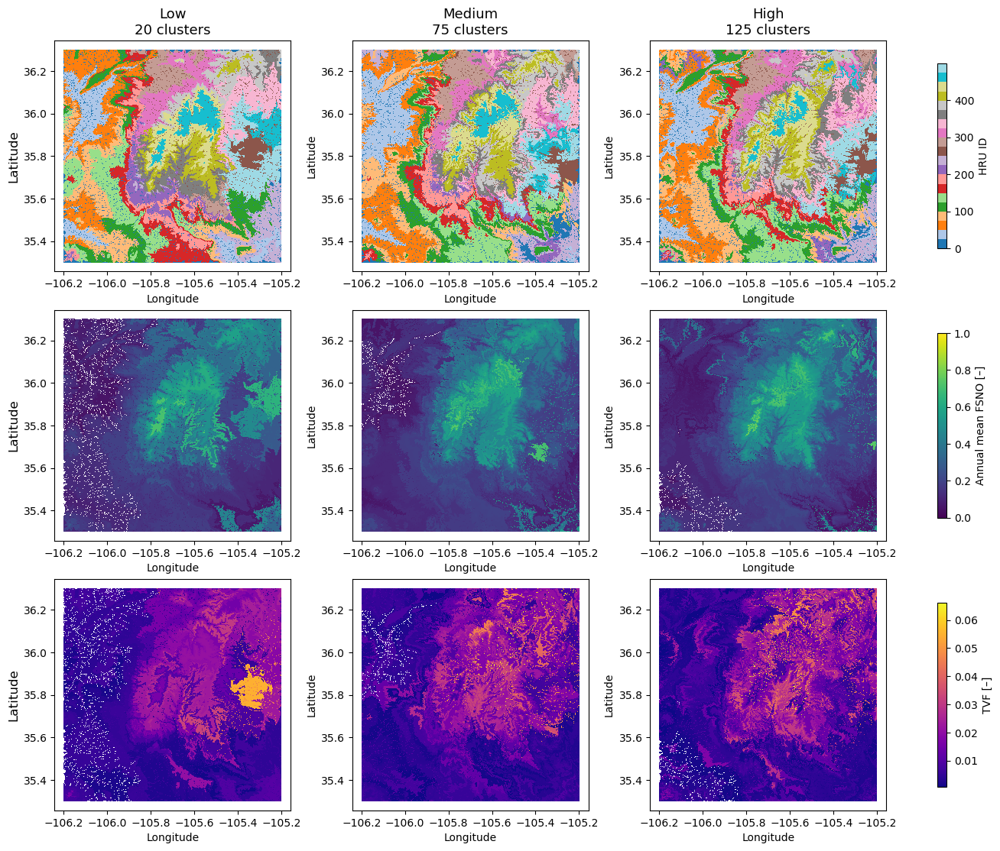

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/HRU_low_medium_high_metrics/paper_style_HRU_FSNO_TVF_low_medium_high.png


In [19]:
#
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Low\n20 clusters": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/",
    "Medium\n75 clusters": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/",
    "High\n125 clusters": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/HRU_low_medium_high_metrics"
os.makedirs(outputdir, exist_ok=True)

buffer = 250


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def read_fsno(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["fsno"][:])
    fp.close()
    return data


def read_param(path, paramname):
    fp = nc.Dataset(path + "/1/input_file.nc")
    data = np.array(fp.groups["parameters"].variables[paramname][:])
    fp.close()
    return data


def clean_and_crop(arr):
    arr = np.where(arr == -9999.0, np.nan, arr)
    return arr[buffer:arr.shape[0]-buffer+1, buffer:arr.shape[1]-buffer+1]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    fsno = read_fsno(path)
    fsno_mean_hru = np.nanmean(fsno, axis=0)
    fsno_map = place_data(tmp, fsno_mean_hru, hrus, cids, 1)

    tvf_hru = read_param(path, "tvf")
    tvf_map = place_data(tmp, tvf_hru, hrus, cids, 1)

    hru_map = np.copy(hrus)

    return (
        clean_and_crop(hru_map),
        clean_and_crop(fsno_map),
        clean_and_crop(tvf_map)
    )


first_path = list(runs.values())[0]
meta = gdal_tools.retrieve_metadata(first_path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(meta["minx"], meta["maxx"], meta["nx"])
coord_yy0 = np.linspace(meta["miny"], meta["maxy"], meta["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0)-buffer+1]
coords_y = coord_yy0[buffer:len(coord_yy0)-buffer+1]


hru_maps = []
fsno_maps = []
tvf_maps = []
labels = []

for label, path in runs.items():
    print("Reading:", label)
    hru_map, fsno_map, tvf_map = get_maps(path)

    hru_maps.append(hru_map)
    fsno_maps.append(fsno_map)
    tvf_maps.append(tvf_map)
    labels.append(label)


fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

tvf_min = np.nanmin([np.nanmin(m) for m in tvf_maps])
tvf_max = np.nanmax([np.nanmax(m) for m in tvf_maps])
tvf_norm = colors.Normalize(vmin=tvf_min, vmax=tvf_max)


fig, axes = plt.subplots(3, 3, figsize=(13, 11), constrained_layout=True)

for col in range(3):

    im0 = axes[0, col].pcolormesh(
        coords_x, coords_y, np.flipud(hru_maps[col]),
        cmap="tab20",
        shading="auto"
    )
    axes[0, col].set_title(labels[col], fontsize=13)

    im1 = axes[1, col].pcolormesh(
        coords_x, coords_y, np.flipud(fsno_maps[col]),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    im2 = axes[2, col].pcolormesh(
        coords_x, coords_y, np.flipud(tvf_maps[col]),
        cmap="plasma",
        norm=tvf_norm,
        shading="auto"
    )


axes[0, 0].set_ylabel("HRU distribution", fontsize=12)
axes[1, 0].set_ylabel("Annual mean FSNO", fontsize=12)
axes[2, 0].set_ylabel("Terrain View Factor", fontsize=12)

for i in range(3):
    for j in range(3):
        axes[i, j].set_xlabel("Longitude")
        axes[i, j].set_ylabel("Latitude")


cbar0 = fig.colorbar(im0, ax=axes[0, :], shrink=0.8)
cbar0.set_label("HRU ID")

cbar1 = fig.colorbar(im1, ax=axes[1, :], shrink=0.8)
cbar1.set_label("Annual mean FSNO [–]")

cbar2 = fig.colorbar(im2, ax=axes[2, :], shrink=0.8)
cbar2.set_label("TVF [–]")


outfile = os.path.join(outputdir, "paper_style_HRU_FSNO_TVF_low_medium_high.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

In [18]:
#Errors and bias

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Low_PP_test1": {
        "path": base + "/MSWX_3h_Snow_Project3_pp_septiles_downscale_test_1/",
        "hru_level": "Low",
        "physics": "PP",
        "subbasins": 2,
        "bands": 500,
        "clusters": 20,
    },
    "Low_3D_test1": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/",
        "hru_level": "Low",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 20,
    },
    "Medium_PP_test2": {
        "path": base + "/MSWX_3h_Snow_Project3_pp_septiles_downscale_test_2/",
        "hru_level": "Medium",
        "physics": "PP",
        "subbasins": 2,
        "bands": 500,
        "clusters": 75,
    },
    "Medium_3D_test2": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/",
        "hru_level": "Medium",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 75,
    },
    "High_PP_test3": {
        "path": base + "/MSWX_3h_Snow_Project3_pp_septiles_downscale_test_3/",
        "hru_level": "High",
        "physics": "PP",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },
    "High_3D_test3": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
        "hru_level": "High",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },
}

modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/HRU_low_medium_high_metrics"
os.makedirs(outputdir, exist_ok=True)

buffer = 250


seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}


def read_model_var(path, varname="fsno"):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables[varname][:])
    fp.close()
    return data


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def model_season_map(path, season_months, varname="fsno"):
    data = read_model_var(path, varname)

    ntime = data.shape[0]
    times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

    mask = times.month.isin(season_months)
    mean_hru = np.nanmean(data[mask, :], axis=0)

    hrus = gdal_tools.read_raster(path + "/postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "/postprocess/cids.vrt")
    tmp = np.full(hrus.shape, -9999.0)

    grid = place_data(tmp, mean_hru, hrus, cids, 1)
    grid = np.where(grid == -9999.0, np.nan, grid)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")


def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []

    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue

        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)

        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError("No MODSCAG files found")

    return rows


def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()

    return arr / 100.0


def modscag_season_map(rows, season_months):
    arrs = []

    for dt, fp in rows:
        if dt.month in season_months:
            arrs.append(read_modscag_grid(fp))

    if len(arrs) == 0:
        return None

    grid = np.nanmean(np.stack(arrs, axis=0), axis=0)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


def calc_metrics(model_map, obs_map):
    valid = np.isfinite(model_map) & np.isfinite(obs_map)

    if np.sum(valid) == 0:
        return np.nan, np.nan, np.nan, np.nan

    diff = model_map[valid] - obs_map[valid]

    bias = np.nanmean(diff)
    rmse = np.sqrt(np.nanmean(diff**2))
    mae = np.nanmean(np.abs(diff))
    corr = np.corrcoef(model_map[valid].ravel(), obs_map[valid].ravel())[0, 1]

    return bias, rmse, mae, corr


modscag_rows = build_modscag_rows(modscag_sat)

rows = []

for run_name, info in runs.items():
    path = info["path"]
    print("Processing:", run_name)

    for season, months in seasons.items():

        model_map = model_season_map(path, months, varname="fsno")
        obs_map = modscag_season_map(modscag_rows, months)

        if obs_map is None:
            continue

        if model_map.shape != obs_map.shape:
            raise ValueError(f"Shape mismatch: {model_map.shape} vs {obs_map.shape}")

        bias, rmse, mae, corr = calc_metrics(model_map, obs_map)

        rows.append({
            "run": run_name,
            "hru_level": info["hru_level"],
            "physics": info["physics"],
            "subbasins": info["subbasins"],
            "band_spacing_m": info["bands"],
            "clusters": info["clusters"],
            "season": season,
            "bias": bias,
            "rmse": rmse,
            "mae": mae,
            "corr": corr,
        })


df_metrics = pd.DataFrame(rows)

outfile = os.path.join(outputdir, "HRU_low_medium_high_FSNO_MODSCAG_metrics.csv")
df_metrics.to_csv(outfile, index=False)

print("Saved:", outfile)
df_metrics

Processing: Low_PP_test1


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1620990/1097690797.py:167: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1620990/1097690797.py:167: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Low_3D_test1


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1620990/1097690797.py:167: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1620990/1097690797.py:167: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Medium_PP_test2


...

/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1620990/1097690797.py:167: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1620990/1097690797.py:167: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: High_3D_test3


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1620990/1097690797.py:167: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1620990/1097690797.py:167: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/HRU_low_medium_high_metrics/HRU_low_medium_high_FSNO_MODSCAG_metrics.csv


,run,hru_level,physics,subbasins,band_spacing_m,clusters,season,bias,rmse,mae,corr
0,Low_PP_test1,Low,PP,2,500,20,Winter,0.426588,0.456036,0.427033,0.707426
1,Low_PP_test1,Low,PP,2,500,20,Spring,0.247107,0.373414,0.249437,0.592523
2,Low_PP_test1,Low,PP,2,500,20,Summer,0.025065,0.072472,0.025256,0.338773
3,Low_PP_test1,Low,PP,2,500,20,Fall,0.085403,0.107185,0.085912,0.613306
4,Low_3D_test1,Low,3D,2,500,20,Winter,0.393983,0.426371,0.394681,0.701769
5,Low_3D_test1,Low,3D,2,500,20,Spring,0.234996,0.362516,0.237447,0.595804
6,Low_3D_test1,Low,3D,2,500,20,Summer,0.025816,0.074794,0.026010,0.333973
7,Low_3D_test1,Low,3D,2,500,20,Fall,0.080548,0.102853,0.081155,0.613369
8,Medium_PP_test2,Medium,PP,2,500,75,Winter,0.434842,0.457784,0.434899,0.765906
9,Medium_PP_test2,Medium,PP,2,500,75,Spring,0.238638,0.352990,0.238659,0.666168


In [3]:

#compares your model FSNO against MODSCAG snow fraction defualt configuration
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "PP_downscale_new": {
        "path": base + "/MSWX_3h_Snow_Project3_pp_downscale_new/",
        "physics": "PP",
    },
    "3D_downscale_new": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_downscale_new/",
        "physics": "3D",
    },
}

modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/downscale_new_MODSCAG_metrics"
os.makedirs(outputdir, exist_ok=True)

buffer = 250

seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

def read_model_var(path, varname="fsno"):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables[varname][:])
    fp.close()
    return data

def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

def model_season_map(path, season_months, varname="fsno"):
    data = read_model_var(path, varname)

    ntime = data.shape[0]
    times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

    mask = times.month.isin(season_months)
    mean_hru = np.nanmean(data[mask, :], axis=0)

    hrus = gdal_tools.read_raster(path + "/postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "/postprocess/cids.vrt")
    tmp = np.full(hrus.shape, -9999.0)

    grid = place_data(tmp, mean_hru, hrus, cids, 1)
    grid = np.where(grid == -9999.0, np.nan, grid)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]

pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []

    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue

        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)

        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError("No MODSCAG files found for 2016–2018")

    return rows

def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()

    return arr / 100.0

def modscag_season_map(rows, season_months):
    arrs = []

    for dt, fp in rows:
        if dt.month in season_months:
            arrs.append(read_modscag_grid(fp))

    if len(arrs) == 0:
        return None

    grid = np.nanmean(np.stack(arrs, axis=0), axis=0)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]

def calc_metrics(model_map, obs_map):
    valid = np.isfinite(model_map) & np.isfinite(obs_map)

    if np.sum(valid) == 0:
        return np.nan, np.nan, np.nan, np.nan

    diff = model_map[valid] - obs_map[valid]

    bias = np.nanmean(diff)
    rmse = np.sqrt(np.nanmean(diff**2))
    mae = np.nanmean(np.abs(diff))
    corr = np.corrcoef(model_map[valid].ravel(), obs_map[valid].ravel())[0, 1]

    return bias, rmse, mae, corr

modscag_rows = build_modscag_rows(modscag_sat)

rows = []

for run_name, info in runs.items():
    path = info["path"]

    print("Processing:", run_name)

    for season, months in seasons.items():

        model_map = model_season_map(path, months, varname="fsno")
        obs_map = modscag_season_map(modscag_rows, months)

        if obs_map is None:
            continue

        if model_map.shape != obs_map.shape:
            raise ValueError(f"Shape mismatch: {model_map.shape} vs {obs_map.shape}")

        bias, rmse, mae, corr = calc_metrics(model_map, obs_map)

        rows.append({
            "run": run_name,
            "physics": info["physics"],
            "season": season,
            "bias": bias,
            "rmse": rmse,
            "mae": mae,
            "corr": corr,
        })

df_downscale_metrics = pd.DataFrame(rows)

outfile = os.path.join(outputdir, "PP_3D_downscale_new_FSNO_MODSCAG_metrics.csv")
df_downscale_metrics.to_csv(outfile, index=False)

print("Saved:", outfile)
df_downscale_metrics

Processing: PP_downscale_new


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1666733/2615070009.py:110: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1666733/2615070009.py:110: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: 3D_downscale_new


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1666733/2615070009.py:110: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1666733/2615070009.py:110: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/downscale_new_MODSCAG_metrics/PP_3D_downscale_new_FSNO_MODSCAG_metrics.csv


,run,physics,season,bias,rmse,mae,corr
0,PP_downscale_new,PP,Winter,0.324046,0.379952,0.332269,0.667176
1,PP_downscale_new,PP,Spring,0.147561,0.281700,0.158342,0.550573
2,PP_downscale_new,PP,Summer,0.004281,0.022345,0.005158,0.180467
3,PP_downscale_new,PP,Fall,0.053379,0.068796,0.058103,0.598997
4,3D_downscale_new,3D,Winter,0.320361,0.379417,0.330315,0.634979
5,3D_downscale_new,3D,Spring,0.139228,0.272364,0.155858,0.510005
6,3D_downscale_new,3D,Summer,0.004564,0.024442,0.005511,0.166745
7,3D_downscale_new,3D,Fall,0.053411,0.069550,0.059131,0.553609


In [4]:
import netCDF4 as nc
import os

#base = "/Users/bernardnkrumahattobrah/Documents/HydroBlocks/data/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_Bernard"
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations//MSWX_3h_Snow_Project3_pp_septiles_downscale_test_3/"
cid = 1

input_file = os.path.join(path_pp, f"{cid}/input_file.nc")
output_file = os.path.join(path_pp, f"output_data/{cid}/2016-01-01.nc")

def list_nc_vars(path):
    print(f"\n--- File: {path} ---")
    with nc.Dataset(path) as ds:
        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(f"  {vname:20s} shape={var.shape} dims={var.dimensions}")

# Inspect static (parameters/meteorology)
list_nc_vars(input_file)

# Inspect dynamic outputs
list_nc_vars(output_file)



--- File: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations//MSWX_3h_Snow_Project3_pp_septiles_downscale_test_3/1/input_file.nc ---

[Group: meteorology]
  lwdown               shape=(8744, 500) dims=('time', 'hru')
  swdown               shape=(8744, 500) dims=('time', 'hru')
  tair                 shape=(8744, 500) dims=('time', 'hru')
  precip               shape=(8744, 500) dims=('time', 'hru')
  psurf                shape=(8744, 500) dims=('time', 'hru')
  wind                 shape=(8744, 500) dims=('time', 'hru')
  spfh                 shape=(8744, 500) dims=('time', 'hru')
  time                 shape=(8744,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                 shape=(4,) dims=('connections_columns',)
  indices              shape=(4,) dims=('connections_columns',)
  indptr               shape=(3,) dims=('connections_rows',)

[Group: wmatrix_Basin2]
  data                 shape=(4,) dims=('connect

# COVARIATES TEST Base
MSWX_3h_Snow_Project3_pp_septiles_downscale_test_3
subbasin_clustering_covariates: dem,lats,lons
intraband_clustering_covariates: dem,lats,lons

# COVARIATES TEST 1: Aspect only

"MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_1"

subbasin_clustering_covariates: dem,x_aspect,y_aspect,lats,lons
intraband_clustering_covariates: dem,x_aspect,y_aspect,lats,lons

# COVARIATES TEST 2: location/position + Aspect 
"MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2"

subbasin_clustering_covariates": dem,x_aspect,y_aspect,lats,lons,svf,tvf
intraband_clustering_covariates": dem,x_aspect,y_aspect,lats,lons,slope,svf,tvf

Note: Use only tvf

# COVARIATES TEST 3: Terrain-radiation
"MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3"
subbasin_clustering_covariates": dem,x_aspect,y_aspect,lats,lons,svf,tvf
intraband_clustering_covariates": dem,x_aspect,y_aspect,slope,svf,tvf

# COVARIATES TEST 4: Full terrain + soil + landcover
"MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4"
subbasin_clustering_covariates": dem,x_aspect,y_aspect,lats,lons,svf,tvf
intraband_clustering_covariates": lc,clay,dem,x_aspect,y_aspect,slope,svf,tvf

# COVARIATES TEST 5: Full set without lat/long
"MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5"
subbasin_clustering_covariates: dem,x_aspect,y_aspect,svf,tvf
intraband_clustering_covariates: lc,clay,dem,x_aspect,y_aspect,slope,svf,tvf

# COVARIATES TEST 6: Reduced strong predictors
"MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6"
subbasin_clustering_covariates: dem,slope
intraband_clustering_covariates: dem,slope,clay

# COVARIATES TEST 7: other
"MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_7"
subbasin_clustering_covariates: dem,lats,lons
intraband_clustering_covariates: dem,slope,x_aspect, y_aspect, tvf

# COVARIATES TEST 8: other
"MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_8"
subbasin_clustering_covariates: dem,lats,lons, slope
intraband_clustering_covariates: dem,slope,x_aspect, y_aspect, tvf

Reading: Base
DEM+Lat/Lon
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/
Reading: Cov 1
Aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_1/
Reading: Cov 2
Loc+Aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/
Reading: Cov 3
Terrain-rad
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3/
Reading: Cov 4
Full
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/
Reading: Cov 5
No lat/lon
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/
Reading: Cov

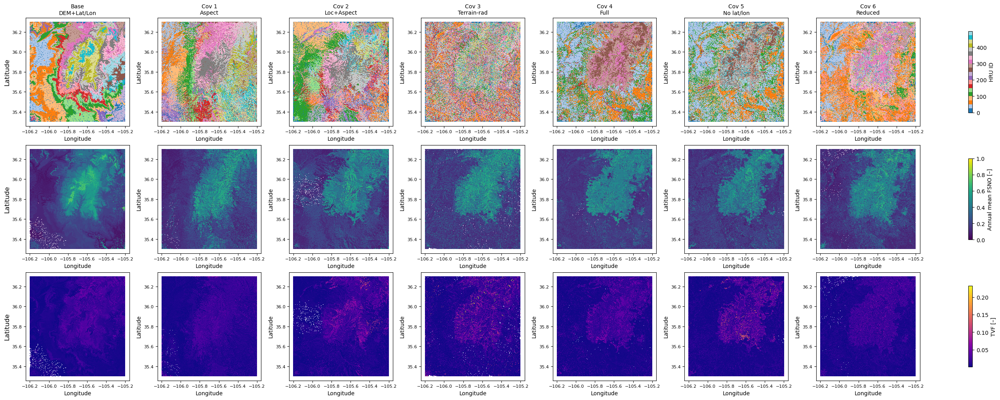

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity/covariates_HRU_FSNO_TVF.png


In [12]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Base\nDEM+Lat/Lon": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
    "Cov 1\nAspect": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_1/",
    "Cov 2\nLoc+Aspect": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/",
    "Cov 3\nTerrain-rad": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3/",
    "Cov 4\nFull": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/",
    "Cov 5\nNo lat/lon": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/",
    "Cov 6\nReduced": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6/",
}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity"
os.makedirs(outputdir, exist_ok=True)

buffer = 250


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def read_fsno(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["fsno"][:])
    fp.close()
    return data


def read_param(path, paramname):
    fp = nc.Dataset(path + "/1/input_file.nc")
    data = np.array(fp.groups["parameters"].variables[paramname][:])
    fp.close()
    return data


def clean_and_crop(arr):
    arr = np.where(arr == -9999.0, np.nan, arr)
    return arr[
        buffer:arr.shape[0]-buffer+1,
        buffer:arr.shape[1]-buffer+1
    ]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    fsno = read_fsno(path)
    fsno_mean_hru = np.nanmean(fsno, axis=0)
    fsno_map = place_data(tmp, fsno_mean_hru, hrus, cids, 1)

    tvf_hru = read_param(path, "tvf")
    tvf_map = place_data(tmp, tvf_hru, hrus, cids, 1)

    hru_map = np.copy(hrus)

    return (
        clean_and_crop(hru_map),
        clean_and_crop(fsno_map),
        clean_and_crop(tvf_map)
    )


first_path = list(runs.values())[0]
meta = gdal_tools.retrieve_metadata(first_path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(meta["minx"], meta["maxx"], meta["nx"])
coord_yy0 = np.linspace(meta["miny"], meta["maxy"], meta["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0)-buffer+1]
coords_y = coord_yy0[buffer:len(coord_yy0)-buffer+1]


hru_maps = []
fsno_maps = []
tvf_maps = []
labels = []

for label, path in runs.items():
    print("Reading:", label)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    hru_file = path + "postprocess/hrus.vrt"
    cid_file = path + "postprocess/cids.vrt"
    out_file = path + "/output_data/1/2016-01-01.nc"
    inp_file = path + "/1/input_file.nc"

    if not os.path.exists(hru_file):
        print("Missing HRU file, skipping:", hru_file)
        continue

    if not os.path.exists(cid_file):
        print("Missing CID file, skipping:", cid_file)
        continue

    if not os.path.exists(out_file):
        print("Missing output file, skipping:", out_file)
        continue

    if not os.path.exists(inp_file):
        print("Missing input file, skipping:", inp_file)
        continue

    hru_map, fsno_map, tvf_map = get_maps(path)

    hru_maps.append(hru_map)
    fsno_maps.append(fsno_map)
    tvf_maps.append(tvf_map)
    labels.append(label)


if len(labels) == 0:
    raise RuntimeError("No valid runs found. Check paths and filenames.")


fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

tvf_min = np.nanmin([np.nanmin(m) for m in tvf_maps])
tvf_max = np.nanmax([np.nanmax(m) for m in tvf_maps])
tvf_norm = colors.Normalize(vmin=tvf_min, vmax=tvf_max)


ncols = len(labels)

fig, axes = plt.subplots(
    3, ncols,
    figsize=(3.6 * ncols, 10),
    constrained_layout=True
)

if ncols == 1:
    axes = axes.reshape(3, 1)


for col in range(ncols):

    im0 = axes[0, col].pcolormesh(
        coords_x, coords_y, np.flipud(hru_maps[col]),
        cmap="tab20",
        shading="auto"
    )
    axes[0, col].set_title(labels[col], fontsize=10)

    im1 = axes[1, col].pcolormesh(
        coords_x, coords_y, np.flipud(fsno_maps[col]),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    im2 = axes[2, col].pcolormesh(
        coords_x, coords_y, np.flipud(tvf_maps[col]),
        cmap="plasma",
        norm=tvf_norm,
        shading="auto"
    )


axes[0, 0].set_ylabel("HRU distribution", fontsize=12)
axes[1, 0].set_ylabel("Annual mean FSNO", fontsize=12)
axes[2, 0].set_ylabel("Terrain View Factor", fontsize=12)

for i in range(3):
    for j in range(ncols):
        axes[i, j].set_xlabel("Longitude")
        axes[i, j].set_ylabel("Latitude")
        axes[i, j].tick_params(labelsize=8)


cbar0 = fig.colorbar(im0, ax=axes[0, :], shrink=0.75)
cbar0.set_label("HRU ID")

cbar1 = fig.colorbar(im1, ax=axes[1, :], shrink=0.75)
cbar1.set_label("Annual mean FSNO [–]")

cbar2 = fig.colorbar(im2, ax=axes[2, :], shrink=0.75)
cbar2.set_label("TVF [–]")


outfile = os.path.join(outputdir, "covariates_HRU_FSNO_TVF.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

In [13]:
# Errors and bias for covariate sensitivity tests

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Base_cov_test": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
        "covariate_test": "Base",
        "description": "dem_lats_lons",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov1_aspect": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_1/",
        "covariate_test": "Cov1",
        "description": "aspect",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov2_location_aspect": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/",
        "covariate_test": "Cov2",
        "description": "location_aspect_svf_tvf",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov3_terrain_radiation": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3/",
        "covariate_test": "Cov3",
        "description": "terrain_radiation",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov4_full": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/",
        "covariate_test": "Cov4",
        "description": "full_terrain_soil_landcover",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov5_no_latlon": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/",
        "covariate_test": "Cov5",
        "description": "full_physical_no_latlon",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov6_reduced": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6/",
        "covariate_test": "Cov6",
        "description": "reduced_physical_predictors",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },
}

#modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

modscag_sat = "/projects/battobrah@xsede.org/modscaq_snow_monthly_data/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity"
os.makedirs(outputdir, exist_ok=True)

buffer = 250

seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}


def read_model_var(path, varname="fsno"):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables[varname][:])
    fp.close()
    return data


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def model_season_map(path, season_months, varname="fsno"):
    data = read_model_var(path, varname)

    ntime = data.shape[0]
    times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

    mask = times.month.isin(season_months)
    mean_hru = np.nanmean(data[mask, :], axis=0)

    hrus = gdal_tools.read_raster(path + "/postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "/postprocess/cids.vrt")
    tmp = np.full(hrus.shape, -9999.0)

    grid = place_data(tmp, mean_hru, hrus, cids, 1)
    grid = np.where(grid == -9999.0, np.nan, grid)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")


def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []

    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue

        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)

        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError("No MODSCAG files found")

    return rows


def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()

    return arr / 100.0


def modscag_season_map(rows, season_months):
    arrs = []

    for dt, fp in rows:
        if dt.month in season_months:
            arrs.append(read_modscag_grid(fp))

    if len(arrs) == 0:
        return None

    grid = np.nanmean(np.stack(arrs, axis=0), axis=0)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


def calc_metrics(model_map, obs_map):
    valid = np.isfinite(model_map) & np.isfinite(obs_map)

    if np.sum(valid) == 0:
        return np.nan, np.nan, np.nan, np.nan

    diff = model_map[valid] - obs_map[valid]

    bias = np.nanmean(diff)
    rmse = np.sqrt(np.nanmean(diff**2))
    mae = np.nanmean(np.abs(diff))
    corr = np.corrcoef(model_map[valid].ravel(), obs_map[valid].ravel())[0, 1]

    return bias, rmse, mae, corr


modscag_rows = build_modscag_rows(modscag_sat)

rows = []

for run_name, info in runs.items():
    path = info["path"]
    print("Processing:", run_name)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    if not os.path.exists(path + "/output_data/1/2016-01-01.nc"):
        print("Missing model output, skipping:", path)
        continue

    if not os.path.exists(path + "/postprocess/hrus.vrt"):
        print("Missing HRU raster, skipping:", path)
        continue

    if not os.path.exists(path + "/postprocess/cids.vrt"):
        print("Missing CID raster, skipping:", path)
        continue

    for season, months in seasons.items():

        model_map = model_season_map(path, months, varname="fsno")
        obs_map = modscag_season_map(modscag_rows, months)

        if obs_map is None:
            continue

        if model_map.shape != obs_map.shape:
            raise ValueError(f"Shape mismatch for {run_name} {season}: {model_map.shape} vs {obs_map.shape}")

        bias, rmse, mae, corr = calc_metrics(model_map, obs_map)

        rows.append({
            "run": run_name,
            "covariate_test": info["covariate_test"],
            "description": info["description"],
            "physics": info["physics"],
            "subbasins": info["subbasins"],
            "band_spacing_m": info["bands"],
            "clusters": info["clusters"],
            "season": season,
            "bias": bias,
            "rmse": rmse,
            "mae": mae,
            "corr": corr,
        })


df_cov_metrics = pd.DataFrame(rows)

outfile = os.path.join(outputdir, "covariate_sensitivity_FSNO_MODSCAG_metrics.csv")
df_cov_metrics.to_csv(outfile, index=False)

print("Saved:", outfile)
df_cov_metrics

Processing: Base_cov_test
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_66281/801377033.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_66281/801377033.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Cov1_aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_1/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_66281/801377033.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_66281/801377033.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Cov2_location_aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/


...

Processing: Cov6_reduced
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_66281/801377033.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_66281/801377033.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity/covariate_sensitivity_FSNO_MODSCAG_metrics.csv


,run,covariate_test,description,physics,subbasins,band_spacing_m,clusters,season,bias,rmse,mae,corr
0,Base_cov_test,Base,dem_lats_lons,3D,2,500,125,Winter,0.398947,0.423659,0.399129,0.769226
1,Base_cov_test,Base,dem_lats_lons,3D,2,500,125,Spring,0.220149,0.334179,0.220285,0.677677
2,Base_cov_test,Base,dem_lats_lons,3D,2,500,125,Summer,0.022659,0.070283,0.022853,0.419161
3,Base_cov_test,Base,dem_lats_lons,3D,2,500,125,Fall,0.078055,0.095539,0.078560,0.725153
4,Cov1_aspect,Cov1,aspect,3D,2,500,125,Winter,0.424929,0.462417,0.427678,0.616059
5,Cov1_aspect,Cov1,aspect,3D,2,500,125,Spring,0.222814,0.353167,0.230210,0.513905
6,Cov1_aspect,Cov1,aspect,3D,2,500,125,Summer,0.019087,0.060873,0.019715,0.195390
7,Cov1_aspect,Cov1,aspect,3D,2,500,125,Fall,0.079744,0.099673,0.082834,0.556180
8,Cov2_location_aspect,Cov2,location_aspect_svf_tvf,3D,2,500,125,Winter,0.424440,0.468681,0.429108,0.513407
9,Cov2_location_aspect,Cov2,location_aspect_svf_tvf,3D,2,500,125,Spring,0.214669,0.338267,0.224137,0.485062


: 

T1:2, 500, 125
T2: 20, 500, 125
T3: 25, 25, 125. - 311
T4: 25, 100, 125 - 3111

Reading: Base
DEM+Lat/Lon
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_11/


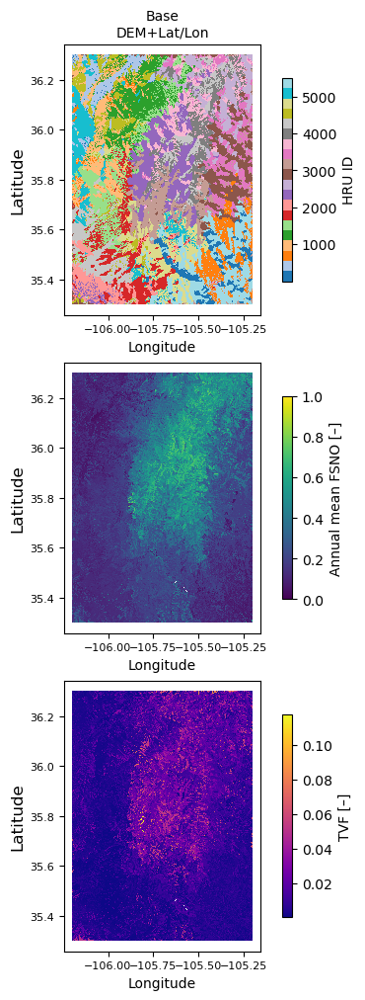

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity/covariates_HRU_FSNO_TVF_masked.png


In [2]:
import os, glob, re
import xarray as xr
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Base\nDEM+Lat/Lon": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_11/"}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity"
os.makedirs(outputdir, exist_ok=True)

buffer = 250


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def read_fsno(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["fsno"][:])
    fp.close()
    return data


def read_param(path, paramname):
    fp = nc.Dataset(path + "/1/input_file.nc")
    data = np.array(fp.groups["parameters"].variables[paramname][:])
    fp.close()
    return data


def clean_and_crop(arr):
    arr = np.array(arr, dtype=float)

    # Mask common invalid/no-data values
    arr = np.where(arr == -9999.0, np.nan, arr)
    arr = np.where(arr == 0.0, np.nan, arr)

    return arr[
        buffer:arr.shape[0]-buffer+1,
        buffer:arr.shape[1]-buffer+1
    ]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    fsno = read_fsno(path)
    fsno_mean_hru = np.nanmean(fsno, axis=0)
    fsno_map = place_data(tmp, fsno_mean_hru, hrus, cids, 1)

    tvf_hru = read_param(path, "tvf")
    tvf_map = place_data(tmp, tvf_hru, hrus, cids, 1)

    # Mask pixels outside the active basin/domain
    hru_map = np.where((cids == 1) & (hrus > 0), hrus, np.nan)

    # Apply the same basin/domain mask to FSNO and TVF
    valid_mask = (cids == 1) & (hrus > 0)
    fsno_map = np.where(valid_mask, fsno_map, np.nan)
    tvf_map = np.where(valid_mask, tvf_map, np.nan)

    return (
        clean_and_crop(hru_map),
        clean_and_crop(fsno_map),
        clean_and_crop(tvf_map)
    )


first_path = list(runs.values())[0]
meta = gdal_tools.retrieve_metadata(first_path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(meta["minx"], meta["maxx"], meta["nx"])
coord_yy0 = np.linspace(meta["miny"], meta["maxy"], meta["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0)-buffer+1]
coords_y = coord_yy0[buffer:len(coord_yy0)-buffer+1]


hru_maps = []
fsno_maps = []
tvf_maps = []
labels = []

for label, path in runs.items():
    print("Reading:", label)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    hru_file = path + "postprocess/hrus.vrt"
    cid_file = path + "postprocess/cids.vrt"
    out_file = path + "/output_data/1/2016-01-01.nc"
    inp_file = path + "/1/input_file.nc"

    if not os.path.exists(hru_file):
        print("Missing HRU file, skipping:", hru_file)
        continue

    if not os.path.exists(cid_file):
        print("Missing CID file, skipping:", cid_file)
        continue

    if not os.path.exists(out_file):
        print("Missing output file, skipping:", out_file)
        continue

    if not os.path.exists(inp_file):
        print("Missing input file, skipping:", inp_file)
        continue

    hru_map, fsno_map, tvf_map = get_maps(path)

    hru_maps.append(hru_map)
    fsno_maps.append(fsno_map)
    tvf_maps.append(tvf_map)
    labels.append(label)


if len(labels) == 0:
    raise RuntimeError("No valid runs found. Check paths and filenames.")


fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

tvf_min = np.nanmin([np.nanmin(m) for m in tvf_maps])
tvf_max = np.nanmax([np.nanmax(m) for m in tvf_maps])
tvf_norm = colors.Normalize(vmin=tvf_min, vmax=tvf_max)


ncols = len(labels)

fig, axes = plt.subplots(
    3, ncols,
    figsize=(3.6 * ncols, 10),
    constrained_layout=True
)

if ncols == 1:
    axes = axes.reshape(3, 1)


for col in range(ncols):

    im0 = axes[0, col].pcolormesh(
        coords_x, coords_y, np.flipud(hru_maps[col]),
        cmap="tab20",
        shading="auto"
    )
    axes[0, col].set_title(labels[col], fontsize=10)

    im1 = axes[1, col].pcolormesh(
        coords_x, coords_y, np.flipud(fsno_maps[col]),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    im2 = axes[2, col].pcolormesh(
        coords_x, coords_y, np.flipud(tvf_maps[col]),
        cmap="plasma",
        norm=tvf_norm,
        shading="auto"
    )


axes[0, 0].set_ylabel("HRU distribution", fontsize=12)
axes[1, 0].set_ylabel("Annual mean FSNO", fontsize=12)
axes[2, 0].set_ylabel("Terrain View Factor", fontsize=12)

for i in range(3):
    for j in range(ncols):
        axes[i, j].set_xlabel("Longitude")
        axes[i, j].set_ylabel("Latitude")
        axes[i, j].tick_params(labelsize=8)


cbar0 = fig.colorbar(im0, ax=axes[0, :], shrink=0.75)
cbar0.set_label("HRU ID")

cbar1 = fig.colorbar(im1, ax=axes[1, :], shrink=0.75)
cbar1.set_label("Annual mean FSNO [–]")

cbar2 = fig.colorbar(im2, ax=axes[2, :], shrink=0.75)
cbar2.set_label("TVF [–]")


outfile = os.path.join(outputdir, "covariates_HRU_FSNO_TVF_masked.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

In [ ]:
      "dem",
      "x_aspect",
      "y_aspect",
      "lats",
      "lons",
      "tvf"

      "dem",
      "x_aspect",
      "y_aspect",
      "lats",
      "lons",
      "tvf"
      "slope"


Reading: Base
DEM+Lat/Lon
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_31/
Reading: Cov 1
Aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_11/
Reading: Cov 2
Loc+Aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/
Reading: Cov 3
Terrain-rad
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3/
Reading: Cov 4
Full
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/
Reading: Cov 5
No lat/lon
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/
Reading: C

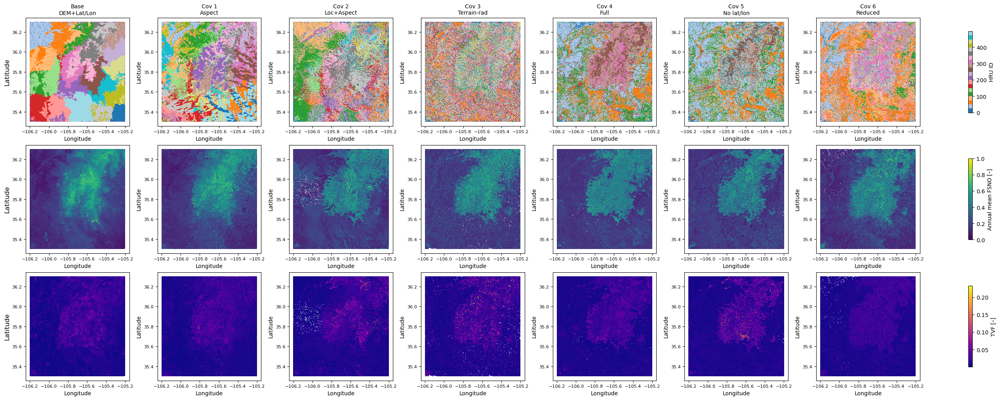

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity/covariates_HRU_FSNO_TVF.png


In [1]:
import os, glob, re
import xarray as xr
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Base\nDEM+Lat/Lon": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_31/",
    "Cov 1\nAspect": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_11/",
    "Cov 2\nLoc+Aspect": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/",
    "Cov 3\nTerrain-rad": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3/",
    "Cov 4\nFull": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/",
    "Cov 5\nNo lat/lon": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/",
    "Cov 6\nReduced": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6/",
}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity"
os.makedirs(outputdir, exist_ok=True)

buffer = 250


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def read_fsno(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["fsno"][:])
    fp.close()
    return data


def read_param(path, paramname):
    fp = nc.Dataset(path + "/1/input_file.nc")
    data = np.array(fp.groups["parameters"].variables[paramname][:])
    fp.close()
    return data


def clean_and_crop(arr):
    arr = np.where(arr == -9999.0, np.nan, arr)
    return arr[
        buffer:arr.shape[0]-buffer+1,
        buffer:arr.shape[1]-buffer+1
    ]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    fsno = read_fsno(path)
    fsno_mean_hru = np.nanmean(fsno, axis=0)
    fsno_map = place_data(tmp, fsno_mean_hru, hrus, cids, 1)

    tvf_hru = read_param(path, "tvf")
    tvf_map = place_data(tmp, tvf_hru, hrus, cids, 1)

    hru_map = np.copy(hrus)

    return (
        clean_and_crop(hru_map),
        clean_and_crop(fsno_map),
        clean_and_crop(tvf_map)
    )


first_path = list(runs.values())[0]
meta = gdal_tools.retrieve_metadata(first_path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(meta["minx"], meta["maxx"], meta["nx"])
coord_yy0 = np.linspace(meta["miny"], meta["maxy"], meta["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0)-buffer+1]
coords_y = coord_yy0[buffer:len(coord_yy0)-buffer+1]


hru_maps = []
fsno_maps = []
tvf_maps = []
labels = []

for label, path in runs.items():
    print("Reading:", label)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    hru_file = path + "postprocess/hrus.vrt"
    cid_file = path + "postprocess/cids.vrt"
    out_file = path + "/output_data/1/2016-01-01.nc"
    inp_file = path + "/1/input_file.nc"

    if not os.path.exists(hru_file):
        print("Missing HRU file, skipping:", hru_file)
        continue

    if not os.path.exists(cid_file):
        print("Missing CID file, skipping:", cid_file)
        continue

    if not os.path.exists(out_file):
        print("Missing output file, skipping:", out_file)
        continue

    if not os.path.exists(inp_file):
        print("Missing input file, skipping:", inp_file)
        continue

    hru_map, fsno_map, tvf_map = get_maps(path)

    hru_maps.append(hru_map)
    fsno_maps.append(fsno_map)
    tvf_maps.append(tvf_map)
    labels.append(label)


if len(labels) == 0:
    raise RuntimeError("No valid runs found. Check paths and filenames.")


fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

tvf_min = np.nanmin([np.nanmin(m) for m in tvf_maps])
tvf_max = np.nanmax([np.nanmax(m) for m in tvf_maps])
tvf_norm = colors.Normalize(vmin=tvf_min, vmax=tvf_max)


ncols = len(labels)

fig, axes = plt.subplots(
    3, ncols,
    figsize=(3.6 * ncols, 10),
    constrained_layout=True
)

if ncols == 1:
    axes = axes.reshape(3, 1)


for col in range(ncols):

    im0 = axes[0, col].pcolormesh(
        coords_x, coords_y, np.flipud(hru_maps[col]),
        cmap="tab20",
        shading="auto"
    )
    axes[0, col].set_title(labels[col], fontsize=10)

    im1 = axes[1, col].pcolormesh(
        coords_x, coords_y, np.flipud(fsno_maps[col]),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    im2 = axes[2, col].pcolormesh(
        coords_x, coords_y, np.flipud(tvf_maps[col]),
        cmap="plasma",
        norm=tvf_norm,
        shading="auto"
    )


axes[0, 0].set_ylabel("HRU distribution", fontsize=12)
axes[1, 0].set_ylabel("Annual mean FSNO", fontsize=12)
axes[2, 0].set_ylabel("Terrain View Factor", fontsize=12)

for i in range(3):
    for j in range(ncols):
        axes[i, j].set_xlabel("Longitude")
        axes[i, j].set_ylabel("Latitude")
        axes[i, j].tick_params(labelsize=8)


cbar0 = fig.colorbar(im0, ax=axes[0, :], shrink=0.75)
cbar0.set_label("HRU ID")

cbar1 = fig.colorbar(im1, ax=axes[1, :], shrink=0.75)
cbar1.set_label("Annual mean FSNO [–]")

cbar2 = fig.colorbar(im2, ax=axes[2, :], shrink=0.75)
cbar2.set_label("TVF [–]")


outfile = os.path.join(outputdir, "covariates_HRU_FSNO_TVF.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

In [3]:
path = runs["Base\nDEM+Lat/Lon"]

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
fsno = read_fsno(path)

nhru = fsno.shape[1]

bad = (cids == 1) & ((hrus <= 0) | (hrus > nhru))
outside_cid = cids != 1

print("nhru:", nhru)
print("bad HRU cells inside cid 1:", np.sum(bad))
print("cells outside cid 1:", np.sum(outside_cid))
print("unique cids:", np.unique(cids))

nhru: 500
bad HRU cells inside cid 1: 822490
cells outside cid 1: 1801200
unique cids: [-9.999e+03  1.000e+00]


# Stats Metrics Checks

In [3]:
# Errors and bias for covariate sensitivity tests

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Base_cov_test": {
        "path": base + "/MSWX_3h_Snow_Project3_pp_septiles_downscale_test_31b/",
        "covariate_test": "Base",
        "description": "dem_lats_lons",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov1_aspect": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_11/",
        "covariate_test": "Cov1",
        "description": "aspect",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov2_location_aspect": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_21/",
        "covariate_test": "Cov2",
        "description": "location_aspect_svf_tvf",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov3_terrain_radiation": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_31/",
        "covariate_test": "Cov3",
        "description": "terrain_radiation",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov4_full": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/",
        "covariate_test": "Cov4",
        "description": "full_terrain_soil_landcover",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov5_no_latlon": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/",
        "covariate_test": "Cov5",
        "description": "full_physical_no_latlon",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },

    "Cov6_reduced": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6/",
        "covariate_test": "Cov6",
        "description": "reduced_physical_predictors",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
    },
}

#modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

modscag_sat = "/projects/battobrah@xsede.org/modscaq_snow_monthly_data/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity"
os.makedirs(outputdir, exist_ok=True)

buffer = 250

seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}


def read_model_var(path, varname="fsno"):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables[varname][:])
    fp.close()
    return data


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def model_season_map(path, season_months, varname="fsno"):
    data = read_model_var(path, varname)

    ntime = data.shape[0]
    times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

    mask = times.month.isin(season_months)
    mean_hru = np.nanmean(data[mask, :], axis=0)

    hrus = gdal_tools.read_raster(path + "/postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "/postprocess/cids.vrt")
    tmp = np.full(hrus.shape, -9999.0)

    grid = place_data(tmp, mean_hru, hrus, cids, 1)
    grid = np.where(grid == -9999.0, np.nan, grid)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")


def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []

    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue

        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)

        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError("No MODSCAG files found")

    return rows


def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()

    return arr / 100.0


def modscag_season_map(rows, season_months):
    arrs = []

    for dt, fp in rows:
        if dt.month in season_months:
            arrs.append(read_modscag_grid(fp))

    if len(arrs) == 0:
        return None

    grid = np.nanmean(np.stack(arrs, axis=0), axis=0)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


def calc_metrics(model_map, obs_map):
    valid = np.isfinite(model_map) & np.isfinite(obs_map)

    if np.sum(valid) == 0:
        return np.nan, np.nan, np.nan, np.nan

    diff = model_map[valid] - obs_map[valid]

    bias = np.nanmean(diff)
    rmse = np.sqrt(np.nanmean(diff**2))
    mae = np.nanmean(np.abs(diff))
    corr = np.corrcoef(model_map[valid].ravel(), obs_map[valid].ravel())[0, 1]

    return bias, rmse, mae, corr


modscag_rows = build_modscag_rows(modscag_sat)

rows = []

for run_name, info in runs.items():
    path = info["path"]
    print("Processing:", run_name)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    if not os.path.exists(path + "/output_data/1/2016-01-01.nc"):
        print("Missing model output, skipping:", path)
        continue

    if not os.path.exists(path + "/postprocess/hrus.vrt"):
        print("Missing HRU raster, skipping:", path)
        continue

    if not os.path.exists(path + "/postprocess/cids.vrt"):
        print("Missing CID raster, skipping:", path)
        continue

    for season, months in seasons.items():

        model_map = model_season_map(path, months, varname="fsno")
        obs_map = modscag_season_map(modscag_rows, months)

        if obs_map is None:
            continue

        if model_map.shape != obs_map.shape:
            raise ValueError(f"Shape mismatch for {run_name} {season}: {model_map.shape} vs {obs_map.shape}")

        bias, rmse, mae, corr = calc_metrics(model_map, obs_map)

        rows.append({
            "run": run_name,
            "covariate_test": info["covariate_test"],
            "description": info["description"],
            "physics": info["physics"],
            "subbasins": info["subbasins"],
            "band_spacing_m": info["bands"],
            "clusters": info["clusters"],
            "season": season,
            "bias": bias,
            "rmse": rmse,
            "mae": mae,
            "corr": corr,
        })


df_cov_metrics = pd.DataFrame(rows)

outfile = os.path.join(outputdir, "covariate_sensitivity_FSNO_MODSCAG_metrics.csv")
df_cov_metrics.to_csv(outfile, index=False)

print("Saved:", outfile)
df_cov_metrics

Processing: Base_cov_test
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_septiles_downscale_test_31b/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2372289/3687269836.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2372289/3687269836.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Cov1_aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_11/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2372289/3687269836.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2372289/3687269836.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Cov2_location_aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_21/
Missing model output, skipping: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_21/
Processing: Cov3_terrain_radiation
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_31/
Missing path, skipping: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_31/
Processing: Cov4_full
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/


...

/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2372289/3687269836.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2372289/3687269836.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Cov6_reduced
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2372289/3687269836.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2372289/3687269836.py:189: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity/covariate_sensitivity_FSNO_MODSCAG_metrics.csv


,run,covariate_test,description,physics,subbasins,band_spacing_m,clusters,season,bias,rmse,mae,corr
0,Base_cov_test,Base,dem_lats_lons,3D,2,500,125,Winter,0.408099,0.427739,0.408123,0.813614
1,Base_cov_test,Base,dem_lats_lons,3D,2,500,125,Spring,0.223687,0.333171,0.223850,0.713187
2,Base_cov_test,Base,dem_lats_lons,3D,2,500,125,Summer,0.025043,0.075548,0.025215,0.466635
3,Base_cov_test,Base,dem_lats_lons,3D,2,500,125,Fall,0.080579,0.096661,0.080780,0.790274
4,Cov1_aspect,Cov1,aspect,3D,2,500,125,Winter,0.429238,0.453791,0.429431,0.756698
5,Cov1_aspect,Cov1,aspect,3D,2,500,125,Spring,0.231860,0.345012,0.232382,0.654166
6,Cov1_aspect,Cov1,aspect,3D,2,500,125,Summer,0.022196,0.068713,0.022449,0.376108
7,Cov1_aspect,Cov1,aspect,3D,2,500,125,Fall,0.081944,0.099440,0.082748,0.708562
8,Cov4_full,Cov4,full_terrain_soil_landcover,3D,2,500,125,Winter,0.431635,0.465960,0.434436,0.579912
9,Cov4_full,Cov4,full_terrain_soil_landcover,3D,2,500,125,Spring,0.214175,0.344756,0.220850,0.503133


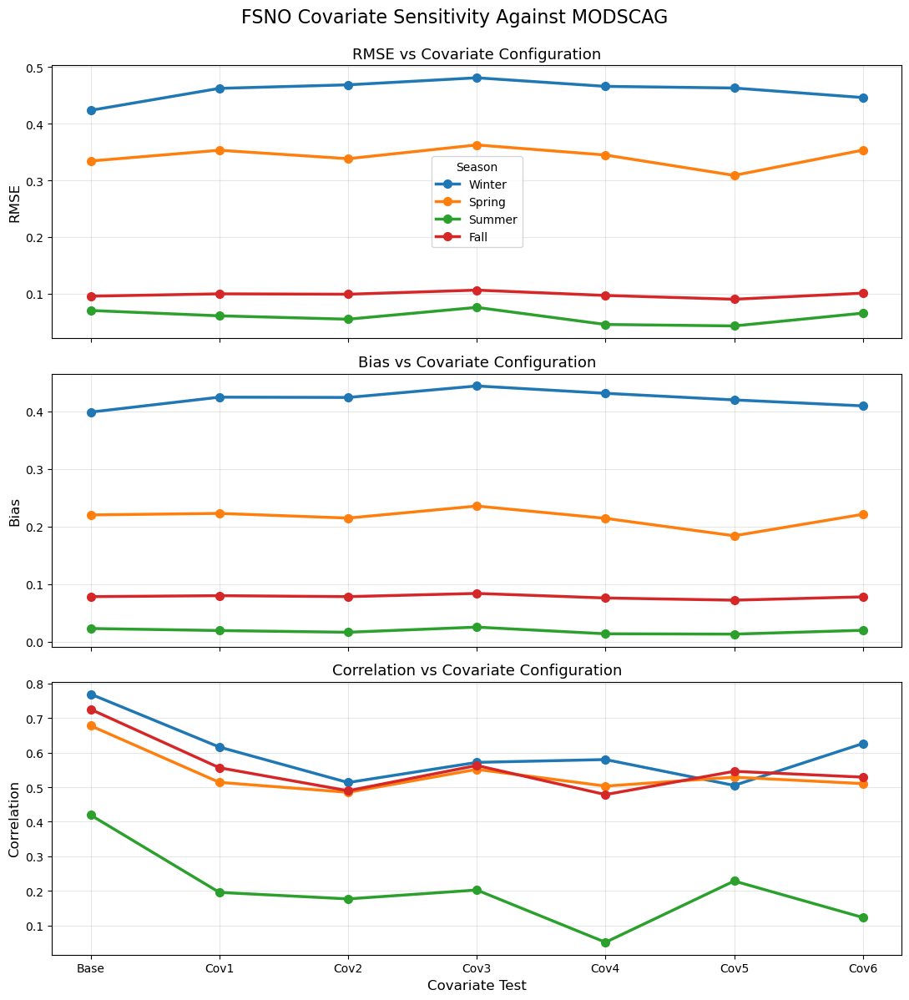

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity/FSNO_covariate_sensitivity_lines.png


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

plot_df = df_cov_metrics.copy()

season_order = ["Winter", "Spring", "Summer", "Fall"]
cov_order = ["Base", "Cov1", "Cov2", "Cov3", "Cov4", "Cov5", "Cov6"]

plot_df["season"] = pd.Categorical(
    plot_df["season"],
    categories=season_order,
    ordered=True
)

plot_df["covariate_test"] = pd.Categorical(
    plot_df["covariate_test"],
    categories=cov_order,
    ordered=True
)

plot_df = plot_df.sort_values(["season", "covariate_test"])

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

metrics = [
    ("rmse", "RMSE"),
    ("bias", "Bias"),
    ("corr", "Correlation"),
]

for ax, (metric, title) in zip(axes, metrics):

    for season in season_order:

        sub = plot_df[plot_df["season"] == season]

        ax.plot(
            sub["covariate_test"],
            sub[metric],
            marker="o",
            linewidth=2.5,
            markersize=7,
            label=season
        )

    ax.set_ylabel(title, fontsize=12)
    ax.set_title(title + " vs Covariate Configuration", fontsize=13)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Covariate Test", fontsize=12)

axes[0].legend(
    loc="best",
    title="Season"
)

plt.suptitle(
    "FSNO Covariate Sensitivity Against MODSCAG",
    fontsize=16,
    y=0.995
)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "FSNO_covariate_sensitivity_lines.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", outfile)

In [9]:
# SMC errors and bias for covariate sensitivity tests
# Difference = Model SMC - SMAP SMC

import os, glob, re
import numpy as np
import pandas as pd
import netCDF4 as nc
import rasterio

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Base_cov_test": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
        "covariate_test": "Base",
        "description": "dem_lats_lons",
    },
    "Cov1_aspect": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_1/",
        "covariate_test": "Cov1",
        "description": "aspect",
    },
    "Cov2_location_aspect": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/",
        "covariate_test": "Cov2",
        "description": "location_aspect_svf_tvf",
    },
    "Cov3_terrain_radiation": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3/",
        "covariate_test": "Cov3",
        "description": "terrain_radiation",
    },
    "Cov4_full": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/",
        "covariate_test": "Cov4",
        "description": "full_terrain_soil_landcover",
    },
    "Cov5_no_latlon": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/",
        "covariate_test": "Cov5",
        "description": "full_physical_no_latlon",
    },
    "Cov6_reduced": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6/",
        "covariate_test": "Cov6",
        "description": "reduced_physical_predictors",
    },
}

smap_sat = "/scratch/alpine/battobrah@xsede.org/smap_monthly_1km_4326_Band_2_MODELGRID_4326"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity"
os.makedirs(outputdir, exist_ok=True)

buffer = 250
smc_layer = 0

seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}


def read_model_var(path, varname="smc", layer=0):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables[varname][:])
    fp.close()

    if data.ndim == 3:
        data = data[:, :, layer]

    return data


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def model_season_map(path, months, varname="smc", layer=0):
    data = read_model_var(path, varname=varname, layer=layer)

    ntime = data.shape[0]
    times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

    mask = times.month.isin(months)
    mean_hru = np.nanmean(data[mask, :], axis=0)

    hrus = gdal_tools.read_raster(path + "/postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "/postprocess/cids.vrt")
    tmp = np.full(hrus.shape, -9999.0)

    grid = place_data(tmp, mean_hru, hrus, cids, 1)
    grid = np.where(grid == -9999.0, np.nan, grid)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


def read_smap_grid(fp):
    with rasterio.open(fp) as ds:
        arr = ds.read(1).astype(np.float32)
        nod = ds.nodata

        if nod is not None:
            arr[arr == nod] = np.nan

        arr[arr == -9999.0] = np.nan

    return arr


def build_smap_rows(smap_folder):
    files = sorted(glob.glob(os.path.join(smap_folder, "*.tif")))
    rows = []

    for fp in files:
        fname = os.path.basename(fp)

        # works for names like SMAP_B2_201601_monthlymean_MODELGRID_4326.tif
        m = re.search(r"(20\d{4})", fname)

        if not m:
            continue

        dt = pd.to_datetime(m.group(1), format="%Y%m")

        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError("No SMAP files found for 2016–2018")

    return rows


def smap_season_map(smap_rows, months):
    arrs = []

    for dt, fp in smap_rows:
        if dt.month in months:
            arrs.append(read_smap_grid(fp))

    if len(arrs) == 0:
        return None

    grid = np.nanmean(np.stack(arrs, axis=0), axis=0)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


def calc_metrics(model_map, smap_map):
    valid = np.isfinite(model_map) & np.isfinite(smap_map)

    if np.sum(valid) == 0:
        return np.nan, np.nan, np.nan, np.nan

    diff = model_map[valid] - smap_map[valid]

    bias = np.nanmean(diff)
    rmse = np.sqrt(np.nanmean(diff**2))
    mae = np.nanmean(np.abs(diff))
    corr = np.corrcoef(model_map[valid].ravel(), smap_map[valid].ravel())[0, 1]

    return bias, rmse, mae, corr


smap_rows = build_smap_rows(smap_sat)

rows = []

for run_name, info in runs.items():
    path = info["path"]

    print("Processing:", run_name)

    for season, months in seasons.items():

        model_map = model_season_map(path, months, varname="smc", layer=smc_layer)
        smap_map = smap_season_map(smap_rows, months)

        if smap_map is None:
            continue

        if model_map.shape != smap_map.shape:
            raise ValueError(f"Shape mismatch: {model_map.shape} vs {smap_map.shape}")

        bias, rmse, mae, corr = calc_metrics(model_map, smap_map)

        rows.append({
            "run": run_name,
            "covariate_test": info["covariate_test"],
            "description": info["description"],
            "variable": "smc",
            "layer": smc_layer,
            "season": season,
            "bias": bias,
            "rmse": rmse,
            "mae": mae,
            "corr": corr,
        })


df_smc_smap_metrics = pd.DataFrame(rows)

outfile = os.path.join(
    outputdir,
    f"covariate_sensitivity_SMC_layer{smc_layer}_SMAP_metrics.csv"
)

df_smc_smap_metrics.to_csv(outfile, index=False)

print("Saved:", outfile)
df_smc_smap_metrics

Processing: Base_cov_test
Processing: Cov1_aspect
Processing: Cov2_location_aspect
Processing: Cov3_terrain_radiation
Processing: Cov4_full
Processing: Cov5_no_latlon
Processing: Cov6_reduced
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity/covariate_sensitivity_SMC_layer0_SMAP_metrics.csv


,run,covariate_test,description,variable,layer,season,bias,rmse,mae,corr
0,Base_cov_test,Base,dem_lats_lons,smc,0,Winter,0.111874,0.116825,0.111874,0.069907
1,Base_cov_test,Base,dem_lats_lons,smc,0,Spring,0.086268,0.092375,0.086270,0.716284
2,Base_cov_test,Base,dem_lats_lons,smc,0,Summer,0.032746,0.046295,0.037530,0.725731
3,Base_cov_test,Base,dem_lats_lons,smc,0,Fall,0.044398,0.053156,0.045788,0.573580
4,Cov1_aspect,Cov1,aspect,smc,0,Winter,0.117576,0.123161,0.117576,-0.113682
5,Cov1_aspect,Cov1,aspect,smc,0,Spring,0.089846,0.098197,0.090205,0.573890
6,Cov1_aspect,Cov1,aspect,smc,0,Summer,0.033609,0.047214,0.038873,0.707584
7,Cov1_aspect,Cov1,aspect,smc,0,Fall,0.048363,0.056204,0.049484,0.596007
8,Cov2_location_aspect,Cov2,location_aspect_svf_tvf,smc,0,Winter,0.115977,0.121866,0.115977,-0.089533
9,Cov2_location_aspect,Cov2,location_aspect_svf_tvf,smc,0,Spring,0.089768,0.097930,0.090111,0.554568


In [8]:
import os, glob

smap_sat = "/scratch/alpine/battobrah@xsede.org/smap_monthly_smc_4326/"

files = sorted(glob.glob(os.path.join(smap_sat, "*")))
print("Number of files:", len(files))

for f in files[:20]:
    print(os.path.basename(f))

Number of files: 0


In [13]:
# Compare Cov7 PP/3D and High_3D_test3 against MODSCAG FSNO
# Difference evaluated using bias, RMSE, MAE, and correlation

import os, glob, re
import numpy as np
import pandas as pd
import netCDF4 as nc
import xarray as xr

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "High_3D_test3": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
        "physics": "3D",
        "subbasins": 2,
        "bands": 500,
        "clusters": 125,
        "description": "2_subbasins_500m_125clusters_dem_lat_lon",
    },

    "Cov7_PP": {
        "path": base + "/MSWX_3h_Snow_Project3_pp_septiles_downscale_cov_7/",
        "physics": "PP",
        "subbasins": 10,
        "bands": 500,
        "clusters": 125,
        "description": "10_subbasins_500m_125clusters_dem_lat_lon",
    },

    "Cov7_3D": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_7/",
        "physics": "3D",
        "subbasins": 10,
        "bands": 500,
        "clusters": 125,
        "description": "10_subbasins_500m_125clusters_dem_lat_lon",
    },
}

modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/cov7_vs_modscag"
os.makedirs(outputdir, exist_ok=True)

buffer = 250

seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}


def read_model_var(path, varname="fsno"):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables[varname][:])
    fp.close()
    return data


def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def model_season_map(path, season_months, varname="fsno"):
    data = read_model_var(path, varname)

    ntime = data.shape[0]
    times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

    mask = times.month.isin(season_months)
    mean_hru = np.nanmean(data[mask, :], axis=0)

    hrus = gdal_tools.read_raster(path + "/postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "/postprocess/cids.vrt")
    tmp = np.full(hrus.shape, -9999.0)

    grid = place_data(tmp, mean_hru, hrus, cids, 1)
    grid = np.where(grid == -9999.0, np.nan, grid)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")


def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []

    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue

        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)

        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError("No MODSCAG files found")

    return rows


def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()

    return arr / 100.0


def modscag_season_map(rows, season_months):
    arrs = []

    for dt, fp in rows:
        if dt.month in season_months:
            arrs.append(read_modscag_grid(fp))

    if len(arrs) == 0:
        return None

    grid = np.nanmean(np.stack(arrs, axis=0), axis=0)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]


def calc_metrics(model_map, obs_map):
    valid = np.isfinite(model_map) & np.isfinite(obs_map)

    if np.sum(valid) == 0:
        return np.nan, np.nan, np.nan, np.nan

    diff = model_map[valid] - obs_map[valid]

    bias = np.nanmean(diff)
    rmse = np.sqrt(np.nanmean(diff**2))
    mae = np.nanmean(np.abs(diff))

    if np.nanstd(model_map[valid]) == 0 or np.nanstd(obs_map[valid]) == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(model_map[valid].ravel(), obs_map[valid].ravel())[0, 1]

    return bias, rmse, mae, corr


modscag_rows = build_modscag_rows(modscag_sat)

rows = []

for run_name, info in runs.items():
    path = info["path"]

    print("Processing:", run_name)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    if not os.path.exists(path + "/output_data/1/2016-01-01.nc"):
        print("Missing model output, skipping:", path)
        continue

    if not os.path.exists(path + "/postprocess/hrus.vrt"):
        print("Missing HRU raster, skipping:", path)
        continue

    if not os.path.exists(path + "/postprocess/cids.vrt"):
        print("Missing CID raster, skipping:", path)
        continue

    for season, months in seasons.items():

        model_map = model_season_map(path, months, varname="fsno")
        obs_map = modscag_season_map(modscag_rows, months)

        if obs_map is None:
            continue

        if model_map.shape != obs_map.shape:
            raise ValueError(
                f"Shape mismatch for {run_name} {season}: "
                f"{model_map.shape} vs {obs_map.shape}"
            )

        bias, rmse, mae, corr = calc_metrics(model_map, obs_map)

        rows.append({
            "run": run_name,
            "physics": info["physics"],
            "description": info["description"],
            "subbasins": info["subbasins"],
            "band_spacing_m": info["bands"],
            "clusters": info["clusters"],
            "season": season,
            "bias": bias,
            "rmse": rmse,
            "mae": mae,
            "corr": corr,
        })


df_cov7_modscag = pd.DataFrame(rows)

outfile = os.path.join(outputdir, "cov7_vs_high3D_FSNO_MODSCAG_metrics.csv")
df_cov7_modscag.to_csv(outfile, index=False)

print("Saved:", outfile)
df_cov7_modscag

Processing: High_3D_test3
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2082121/1003950372.py:151: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2082121/1003950372.py:151: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Cov7_PP
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_septiles_downscale_cov_7/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2082121/1003950372.py:151: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2082121/1003950372.py:151: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: Cov7_3D
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_7/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2082121/1003950372.py:151: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2082121/1003950372.py:151: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/cov7_vs_modscag/cov7_vs_high3D_FSNO_MODSCAG_metrics.csv


,run,physics,description,subbasins,band_spacing_m,clusters,season,bias,rmse,mae,corr
0,High_3D_test3,3D,2_subbasins_500m_125clusters_dem_lat_lon,2,500,125,Winter,0.398947,0.423659,0.399129,0.769226
1,High_3D_test3,3D,2_subbasins_500m_125clusters_dem_lat_lon,2,500,125,Spring,0.220149,0.334179,0.220285,0.677677
2,High_3D_test3,3D,2_subbasins_500m_125clusters_dem_lat_lon,2,500,125,Summer,0.022659,0.070283,0.022853,0.419161
3,High_3D_test3,3D,2_subbasins_500m_125clusters_dem_lat_lon,2,500,125,Fall,0.078055,0.095539,0.078560,0.725153
4,Cov7_PP,PP,10_subbasins_500m_125clusters_dem_lat_lon,10,500,125,Winter,0.435730,0.456734,0.435758,0.789124
5,Cov7_PP,PP,10_subbasins_500m_125clusters_dem_lat_lon,10,500,125,Spring,0.238446,0.349195,0.238505,0.693239
6,Cov7_PP,PP,10_subbasins_500m_125clusters_dem_lat_lon,10,500,125,Summer,0.024694,0.074730,0.024816,0.454708
7,Cov7_PP,PP,10_subbasins_500m_125clusters_dem_lat_lon,10,500,125,Fall,0.085112,0.101824,0.085287,0.777870
8,Cov7_3D,3D,10_subbasins_500m_125clusters_dem_lat_lon,10,500,125,Winter,0.407339,0.429611,0.407401,0.789670
9,Cov7_3D,3D,10_subbasins_500m_125clusters_dem_lat_lon,10,500,125,Spring,0.228172,0.338178,0.228242,0.702738



Reading: Base
DEM+Lat/Lon
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/

Reading: Cov 1
Aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_1/

Reading: Cov 2
Loc+Aspect
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/

Reading: Cov 3
Terrain-rad
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3/

Reading: Cov 4
Full
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/

Reading: Cov 5
No lat/lon
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/

Readi

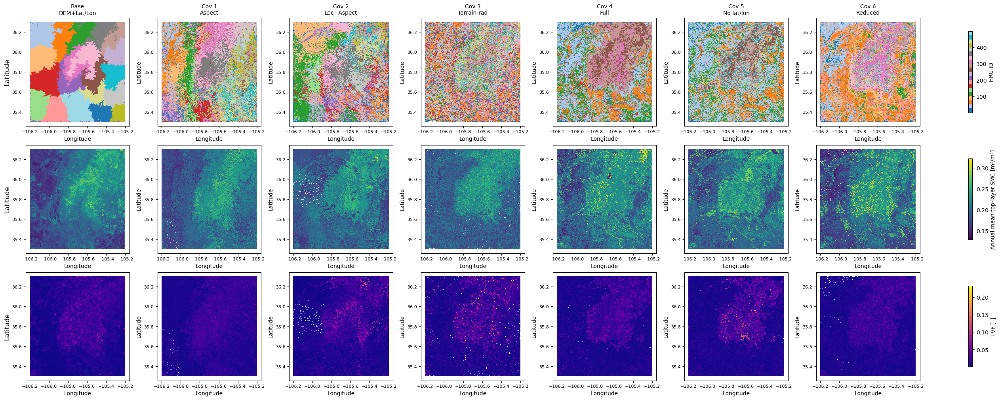

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity/covariates_HRU_toplayerSMC_TVF_all_cids.png


In [4]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Base\nDEM+Lat/Lon": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
    "Cov 1\nAspect": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_1/",
    "Cov 2\nLoc+Aspect": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_2/",
    "Cov 3\nTerrain-rad": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_3/",
    "Cov 4\nFull": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_4/",
    "Cov 5\nNo lat/lon": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_5/",
    "Cov 6\nReduced": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_cov_6/",
}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/covariate_sensitivity"
os.makedirs(outputdir, exist_ok=True)

buffer = 250
smc_layer = 0   # top soil layer


def read_toplayer_smc(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["smc"][:, :, smc_layer])
    fp.close()
    return data


def read_param(path, paramname):
    fp = nc.Dataset(path + "/1/input_file.nc")
    data = np.array(fp.groups["parameters"].variables[paramname][:])
    fp.close()
    return data


def place_data_all_cids(tmp, model_hru, hrus, cids):
    out = np.copy(tmp)

    model_hru = np.asarray(model_hru).squeeze()
    nhru = len(model_hru)

    valid = (
        (cids > 0) &
        (hrus > 0) &
        (hrus <= nhru)
    )

    hru_idx = hrus[valid].astype(int) - 1
    out[valid] = model_hru[hru_idx]

    return out


def clean_and_crop(arr):
    arr = np.where(arr == -9999.0, np.nan, arr)

    return arr[
        buffer:arr.shape[0] - buffer + 1,
        buffer:arr.shape[1] - buffer + 1
    ]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    smc = read_toplayer_smc(path)
    smc_mean_hru = np.nanmean(smc, axis=0)
    smc_mean_hru = np.asarray(smc_mean_hru).squeeze()

    smc_map = place_data_all_cids(tmp, smc_mean_hru, hrus, cids)

    tvf_hru = read_param(path, "tvf")
    tvf_hru = np.asarray(tvf_hru).squeeze()

    tvf_map = place_data_all_cids(tmp, tvf_hru, hrus, cids)

    hru_map = np.copy(hrus)
    hru_map = np.where((cids > 0) & (hrus > 0), hru_map, np.nan)

    return (
        clean_and_crop(hru_map),
        clean_and_crop(smc_map),
        clean_and_crop(tvf_map)
    )


first_path = list(runs.values())[0]
meta = gdal_tools.retrieve_metadata(first_path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(meta["minx"], meta["maxx"], meta["nx"])
coord_yy0 = np.linspace(meta["miny"], meta["maxy"], meta["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]


hru_maps = []
smc_maps = []
tvf_maps = []
labels = []

for label, path in runs.items():
    print("\nReading:", label)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    hru_file = path + "postprocess/hrus.vrt"
    cid_file = path + "postprocess/cids.vrt"
    out_file = path + "/output_data/1/2016-01-01.nc"
    inp_file = path + "/1/input_file.nc"

    if not os.path.exists(hru_file):
        print("Missing HRU file, skipping:", hru_file)
        continue

    if not os.path.exists(cid_file):
        print("Missing CID file, skipping:", cid_file)
        continue

    if not os.path.exists(out_file):
        print("Missing output file, skipping:", out_file)
        continue

    if not os.path.exists(inp_file):
        print("Missing input file, skipping:", inp_file)
        continue

    hru_map, smc_map, tvf_map = get_maps(path)

    hru_maps.append(hru_map)
    smc_maps.append(smc_map)
    tvf_maps.append(tvf_map)
    labels.append(label)


if len(labels) == 0:
    raise RuntimeError("No valid runs found. Check paths and filenames.")


for i, label in enumerate(labels):
    print("\nCheck:", label)
    print("HRU NaN count:", np.sum(~np.isfinite(hru_maps[i])))
    print("SMC NaN count:", np.sum(~np.isfinite(smc_maps[i])))
    print("TVF NaN count:", np.sum(~np.isfinite(tvf_maps[i])))
    print("SMC min/max:", np.nanmin(smc_maps[i]), np.nanmax(smc_maps[i]))
    print("TVF min/max:", np.nanmin(tvf_maps[i]), np.nanmax(tvf_maps[i]))


smc_min = np.nanmin([np.nanmin(m) for m in smc_maps])
smc_max = np.nanmax([np.nanmax(m) for m in smc_maps])
smc_norm = colors.Normalize(vmin=smc_min, vmax=smc_max)

tvf_min = np.nanmin([np.nanmin(m) for m in tvf_maps])
tvf_max = np.nanmax([np.nanmax(m) for m in tvf_maps])
tvf_norm = colors.Normalize(vmin=tvf_min, vmax=tvf_max)


ncols = len(labels)

fig, axes = plt.subplots(
    3, ncols,
    figsize=(3.6 * ncols, 10),
    constrained_layout=True
)

if ncols == 1:
    axes = axes.reshape(3, 1)


hru_cmap = plt.cm.tab20.copy()
hru_cmap.set_bad(color="white")

smc_cmap = plt.cm.viridis.copy()
smc_cmap.set_bad(color="white")

tvf_cmap = plt.cm.plasma.copy()
tvf_cmap.set_bad(color="white")


for col in range(ncols):

    im0 = axes[0, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(hru_maps[col]),
        cmap=hru_cmap,
        shading="auto"
    )
    axes[0, col].set_title(labels[col], fontsize=10)

    im1 = axes[1, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(smc_maps[col]),
        cmap=smc_cmap,
        norm=smc_norm,
        shading="auto"
    )

    im2 = axes[2, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(tvf_maps[col]),
        cmap=tvf_cmap,
        norm=tvf_norm,
        shading="auto"
    )


axes[0, 0].set_ylabel("HRU distribution", fontsize=12)
axes[1, 0].set_ylabel("Annual mean top-layer SMC", fontsize=12)
axes[2, 0].set_ylabel("Terrain View Factor", fontsize=12)

for i in range(3):
    for j in range(ncols):
        axes[i, j].set_xlabel("Longitude")
        axes[i, j].set_ylabel("Latitude")
        axes[i, j].tick_params(labelsize=8)


cbar0 = fig.colorbar(im0, ax=axes[0, :], shrink=0.75)
cbar0.set_label("HRU ID")

cbar1 = fig.colorbar(im1, ax=axes[1, :], shrink=0.75)
cbar1.set_label("Annual mean top-layer SMC [m³/m³]")

cbar2 = fig.colorbar(im2, ax=axes[2, :], shrink=0.75)
cbar2.set_label("TVF [–]")


outfile = os.path.join(outputdir, "covariates_HRU_toplayerSMC_TVF_all_cids.png")

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

In [10]:
import os

# main directory
path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1"

# folders to exclude
exclude_dirs = {
    "backup_forcing",
    "backup_meteo_tifs"
}

total_size = 0

for dirpath, dirnames, filenames in os.walk(path):

    # remove excluded directories from traversal
    dirnames[:] = [d for d in dirnames if d not in exclude_dirs]

    for f in filenames:
        fp = os.path.join(dirpath, f)

        if os.path.isfile(fp):
            total_size += os.path.getsize(fp)

# convert sizes
gb = total_size / (1024**3)
tb = total_size / (1024**4)

print(f"Total size excluding backup folders:")
print(f"{gb:.2f} GB")
print(f"{tb:.3f} TB")

Total size excluding backup folders:
0.31 GB
0.000 TB


In [4]:
import xarray as xr
import os

modscag = "/projects/battobrah@xsede.org/modscaq_snow_monthly_data/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL/MODSCAG_HBclip_ALLVARS_201601_MODELGRID_4326.nc"

ds = xr.open_dataset(modscag)

print(ds)
print("\nDimensions:")
print(ds.dims)

print("\nCoordinates:")
print(ds.coords)

print("\nVariables:")
print(list(ds.data_vars))

<xarray.Dataset>
Dimensions:                         (x: 1801, y: 1801)
Coordinates:
  * x                               (x) float64 -106.4 -106.4 ... -105.0 -104.9
  * y                               (y) float64 36.55 36.55 ... 35.05 35.05
Data variables:
    spatial_ref                     int64 ...
    albedo_clean_flat               (y, x) float32 ...
    albedo_dirty_flat               (y, x) float32 ...
    albedo_clean_terrain_corrected  (y, x) float32 ...
    albedo_dirty_terrain_corrected  (y, x) float32 ...
    deltavis                        (y, x) float32 ...
    grain_size                      (y, x) float32 ...
    drfs_grnsz                      (y, x) float32 ...
    radiative_forcing               (y, x) float32 ...
    snow_fraction                   (y, x) float32 ...
    viewable_snow_fraction          (y, x) float32 ...
    days_without_observation        (y, x) float32 ...

Dimensions:
Frozen({'x': 1801, 'y': 1801})

Coordinates:
Coordinates:
  * x        (x) floa

In [5]:
import rasterio

hb_grid = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/postprocess/hrus.vrt"

with rasterio.open(hb_grid) as ds:
    print("HB width,height:", ds.width, ds.height)
    print("HB bounds:", ds.bounds)
    print("HB res:", ds.res)
    print("HB crs:", ds.crs)

HB width,height: 1801 1801
HB bounds: BoundingBox(left=-106.45041666666549, bottom=35.049583333332606, right=-104.94958333333221, top=36.55041666666588)
HB res: (0.0008333333333333, 0.0008333333333333)
HB crs: EPSG:4326


In [3]:
import numpy as np
import netCDF4 as nc
import os

path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/"

fp = nc.Dataset(path + "/1/input_file.nc")
dem = np.array(fp.groups["parameters"].variables["dem"][:])
fp.close()

dem = dem[np.isfinite(dem)]
dem = dem[dem > -9999]

print("DEM min:", np.min(dem))
print("DEM max:", np.max(dem))
print("DEM mean:", np.mean(dem))
print("DEM std:", np.std(dem))
print("Elevation range:", np.max(dem) - np.min(dem))

for dz in [50, 100, 250, 500, 1000]:
    nbands = (np.max(dem) - np.min(dem)) / dz
    print(f"{dz:4d} m band spacing -> about {nbands:.1f} elevation bands")

DEM min: 1676.337
DEM max: 3912.0293
DEM mean: 2374.4646
DEM std: 453.83224
Elevation range: 2235.6924
  50 m band spacing -> about 44.7 elevation bands
 100 m band spacing -> about 22.4 elevation bands
 250 m band spacing -> about 8.9 elevation bands
 500 m band spacing -> about 4.5 elevation bands
1000 m band spacing -> about 2.2 elevation bands
